# Anomalieerkennung mit DBSCAN am Beispiel von Autodaten

Dieses kompakte Notebook zeigt eine vollständige Vorgehensweise:

1. Beispieldaten erzeugen bzw. reale Daten einlesen
2. Merkmale auswählen und vorbereiten
3. Daten skalieren
4. `min_samples` festlegen
5. `eps` mithilfe eines k-Distanz-Plots abschätzen
6. DBSCAN ausführen
7. gefundene Anomalien untersuchen
8. die Empfindlichkeit gegenüber verschiedenen Parametern prüfen

DBSCAN kennzeichnet Punkte, die zu keinem ausreichend dichten Bereich gehören, mit dem Cluster-Label `-1`. Diese Punkte verwenden wir als mögliche Anomalien.

> **Benötigte Pakete:** `numpy`, `pandas`, `matplotlib` und `scikit-learn`

In [1]:
# Grundlegende Bibliotheken für Datenverarbeitung und Visualisierung
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Werkzeuge aus scikit-learn:
# - RobustScaler: skaliert die Merkmale robust gegenüber Ausreißern
# - NearestNeighbors: berechnet die k-Nachbarschaftsdistanzen
# - DBSCAN: führt die eigentliche dichtebasierte Clusteranalyse durch
from sklearn.preprocessing import RobustScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

# Pandas-Ausgabe etwas übersichtlicher darstellen
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

## 1. Beispieldaten erzeugen

Damit das Notebook ohne externe Datei ausführbar ist, erzeugen wir synthetische Autodaten. Die normalen Fahrzeuge folgen grob plausiblen Zusammenhängen:

- ältere Autos haben tendenziell einen höheren Kilometerstand,
- verschiedene Fahrzeugklassen haben unterschiedliche typische PS-Zahlen,
- zusätzlich fügen wir einige absichtlich ungewöhnliche Fahrzeuge ein.

Bei eigenen Daten kann diese Zelle beispielsweise durch Folgendes ersetzt werden:

```python
df = pd.read_csv("autodaten.csv")
```

Die Spaltennamen müssen dann gegebenenfalls in den späteren Zellen angepasst werden.

In [2]:
# Zufallszahlengenerator mit festem Startwert:
# Dadurch entstehen bei jedem Ausführen dieselben Beispieldaten.
rng = np.random.default_rng(42)

anzahl_normaler_autos = 500

# Alter: überwiegend jüngere bis mittelalte Fahrzeuge, maximal 25 Jahre
alter = np.clip(
    rng.gamma(shape=2.5, scale=3.0, size=anzahl_normaler_autos),
    0,
    25,
)

# Kilometerstand:
# Er hängt grob vom Alter ab, enthält aber auch zufällige Schwankungen.
kilometerstand = np.clip(
    alter * rng.normal(14_000, 3_000, anzahl_normaler_autos)
    + rng.normal(15_000, 12_000, anzahl_normaler_autos),
    0,
    None,
)

# Fahrzeugklassen mit unterschiedlichen typischen PS-Bereichen
fahrzeugklasse = rng.choice(
    ["Kleinwagen", "Mittelklasse", "Sportwagen"],
    size=anzahl_normaler_autos,
    p=[0.45, 0.45, 0.10],
)

ps = np.where(
    fahrzeugklasse == "Kleinwagen",
    rng.normal(95, 18, anzahl_normaler_autos),
    np.where(
        fahrzeugklasse == "Mittelklasse",
        rng.normal(165, 35, anzahl_normaler_autos),
        rng.normal(330, 60, anzahl_normaler_autos),
    ),
)
ps = np.clip(ps, 45, 650)

# Ein grobes Preismerkmal wird nur zur besseren Anschauung erzeugt.
# Für DBSCAN verwenden wir es später bewusst nicht.
preis = np.clip(
    35_000
    + ps * 110
    - alter * 1_800
    - kilometerstand * 0.06
    + rng.normal(0, 5_000, anzahl_normaler_autos),
    1_500,
    None,
)

normale_autos = pd.DataFrame(
    {
        "PS": ps.round(),
        "Kilometerstand": kilometerstand.round(),
        "Alter": alter.round(1),
        "Preis": preis.round(),
        "Fahrzeugklasse": fahrzeugklasse,
        "Künstliche_Anomalie": False,
    }
)

# Absichtlich ungewöhnliche Kombinationen.
# Diese dienen nur dazu, die Arbeitsweise von DBSCAN sichtbar zu machen.
ungewoehnliche_autos = pd.DataFrame(
    [
        [720,   1_500, 18.0, 160_000, "Sonderfall", True],
        [55,  450_000,  2.0,   3_000, "Sonderfall", True],
        [500, 380_000,  1.0,  90_000, "Sonderfall", True],
        [80,    1_000, 28.0,  40_000, "Sonderfall", True],
        [650, 250_000, 24.0, 120_000, "Sonderfall", True],
        [60,        0,  0.0, 120_000, "Sonderfall", True],
        [420,     800,  0.2,   5_000, "Sonderfall", True],
        [20,  520_000, 30.0,   2_500, "Sonderfall", True],
    ],
    columns=normale_autos.columns,
)

# Normale und ungewöhnliche Fahrzeuge zu einer Tabelle verbinden
df = pd.concat(
    [normale_autos, ungewoehnliche_autos],
    ignore_index=True,
)

print(f"Anzahl Fahrzeuge: {len(df)}")
df.head()

Anzahl Fahrzeuge: 508


,PS,Kilometerstand,Alter,Preis,Fahrzeugklasse,Künstliche_Anomalie
0,221.00,"148,309.00",7.90,"38,264.00",Mittelklasse,False
1,173.00,"150,709.00",10.40,"32,209.00",Mittelklasse,False
2,316.00,"125,456.00",7.10,"44,921.00",Sportwagen,False
3,257.00,"106,668.00",6.40,"46,749.00",Sportwagen,False
4,82.00,"163,123.00",11.20,"8,928.00",Kleinwagen,False


In [3]:
# Einen ersten Überblick über Größenordnungen und Verteilungen gewinnen.
# Das ist wichtig, bevor Distanzen zwischen Datenpunkten berechnet werden.
df[["PS", "Kilometerstand", "Alter", "Preis"]].describe()

,PS,Kilometerstand,Alter,Preis
count,508.00,508.00,508.00,508.00
mean,153.15,"119,777.49",7.56,"32,128.11"
std,84.89,"78,894.00",4.91,"16,818.48"
min,20.00,0.00,0.00,"1,500.00"
25%,97.00,"67,438.25",4.00,"22,241.25"
50%,127.00,"104,190.00",6.70,"32,220.50"
75%,182.25,"150,508.00",9.72,"41,306.50"
max,720.00,"557,695.00",30.00,"160,000.00"


## 2. Merkmale auswählen und vorbereiten

Für DBSCAN verwenden wir:

- `PS`
- `Kilometerstand`
- `Alter`

Der Preis wird nicht verwendet, weil er teilweise aus den anderen Merkmalen abgeleitet wurde. Bei realen Daten sollte man nur Merkmale auswählen, die für die Definition von „ungewöhnlich“ fachlich sinnvoll sind.

### Warum logarithmieren wir den Kilometerstand?

Kilometerstände sind häufig stark rechtsschief verteilt: Viele Autos haben moderate Werte, einige wenige sehr hohe. Mit

$\log(1+x)$

werden sehr große Werte zusammengedrückt. `log1p` kann außerdem problemlos mit dem Wert 0 umgehen.

In [4]:
# Nur die numerischen Merkmale auswählen, die DBSCAN verwenden soll.
merkmale = ["PS", "Kilometerstand", "Alter"]
X = df[merkmale].copy()

# Stark große Kilometerstände etwas komprimieren.
# Aus 100.000 und 500.000 km werden dadurch weniger extrem weit
# auseinanderliegende Zahlen als in der ursprünglichen Skala.
X["Kilometerstand"] = np.log1p(X["Kilometerstand"])

X.head()

,PS,Kilometerstand,Alter
0,221.00,11.91,7.90
1,173.00,11.92,10.40
2,316.00,11.74,7.10
3,257.00,11.58,6.40
4,82.00,12.00,11.20


## 3. Warum müssen die Daten skaliert werden?

DBSCAN berechnet Abstände zwischen Datenpunkten. Ohne Skalierung lägen die Merkmale in sehr unterschiedlichen Größenordnungen:

- PS: ungefähr einige Dutzend bis einige Hundert
- Kilometerstand: bis zu mehreren Hunderttausend
- Alter: meistens zwischen 0 und 30

Dann würde der Kilometerstand die Distanz fast vollständig bestimmen.

Wir verwenden den `RobustScaler`. Er zentriert die Werte am Median und skaliert sie mithilfe des Interquartilsabstands. Dadurch wird die Skalierung weniger stark von extremen Werten beeinflusst als beim klassischen Mittelwert und der Standardabweichung.

**Wichtig:** Die Skalierung entfernt keine Ausreißer. Sie sorgt nur dafür, dass die Merkmale bei der Distanzberechnung vergleichbarer gewichtet werden.

In [5]:
# RobustScaler an die ausgewählten und vorbereiteten Daten anpassen
scaler = RobustScaler()

# fit_transform:
# 1. fit: Median und Interquartilsabstand bestimmen
# 2. transform: alle Werte auf dieser Grundlage skalieren
X_skaliert = scaler.fit_transform(X)

# Zur besseren Lesbarkeit wieder als DataFrame darstellen
X_skaliert_df = pd.DataFrame(
    X_skaliert,
    columns=merkmale,
    index=df.index,
)

print("Skalierte Daten:")
X_skaliert_df.head()

Skalierte Daten:


,PS,Kilometerstand,Alter
0,1.10,0.44,0.21
1,0.54,0.46,0.65
2,2.22,0.23,0.07
3,1.52,0.03,-0.05
4,-0.53,0.56,0.79


## 4. `min_samples` festlegen

`min_samples` legt fest, wie viele Punkte sich mindestens in der `eps`-Umgebung eines Punktes befinden müssen, damit dieser Punkt als Kernpunkt gilt.

Eine gebräuchliche Startregel lautet:

$\text{min\_samples} \approx 2 \cdot d$

Dabei ist \(d\) die Anzahl der verwendeten Merkmale. Bei drei Merkmalen beginnen wir daher mit `min_samples = 6`.

Die Regel liefert keinen mathematisch eindeutig optimalen Wert. Ein größerer Wert macht DBSCAN strenger und führt häufig zu mehr als Rauschen markierten Punkten.

In [6]:
# Anzahl der verwendeten Merkmale
anzahl_merkmale = X_skaliert.shape[1]

# Startwert nach der Faustregel 2 * Anzahl der Merkmale
min_samples = 2 * anzahl_merkmale

print(f"Anzahl Merkmale: {anzahl_merkmale}")
print(f"Gewähltes min_samples: {min_samples}")

Anzahl Merkmale: 3
Gewähltes min_samples: 6


## 5. `eps` mit dem k-Distanz-Plot abschätzen

`eps` ist der maximale Radius einer Nachbarschaft.

Für jeden Datenpunkt bestimmen wir die Entfernung zu seinem `min_samples`-ten nächsten Nachbarn. Bei `min_samples = 6` betrachten wir also die Entfernung zum sechstnächsten Punkt.

Danach sortieren wir diese Entfernungen:

- Kleine Werte gehören zu Punkten in dichten Regionen.
- Stark ansteigende Werte gehören zu zunehmend isolierten Punkten.
- Der Bereich, in dem die Kurve deutlich steiler wird, wird häufig als **Knick** oder **Elbow** bezeichnet.
- Ein Wert in der Nähe dieses Knicks ist ein sinnvoller Startwert für `eps`.

Der Knick ist nicht immer eindeutig. Der Plot liefert daher einen Startpunkt, keine automatische Garantie für den besten Parameter.

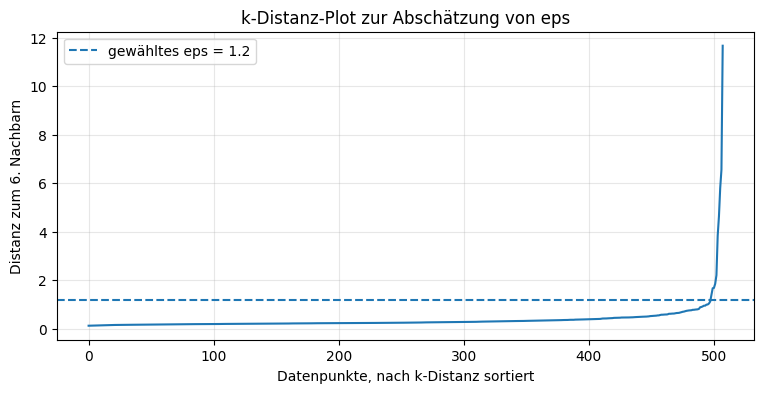

In [7]:
# Für jeden Punkt die min_samples nächsten Nachbarn bestimmen.
# Der Punkt selbst zählt dabei als erster Nachbar mit Distanz 0.
nachbarn = NearestNeighbors(n_neighbors=min_samples)
nachbarn.fit(X_skaliert)

distanzen, indizes = nachbarn.kneighbors(X_skaliert)

# In der letzten Spalte steht die Distanz zum min_samples-ten Nachbarn.
k_distanzen = distanzen[:, -1]

# Sortieren, damit ein möglicher Knick sichtbar wird.
k_distanzen_sortiert = np.sort(k_distanzen)

# Für diese Beispieldaten liegt der sichtbare Übergangsbereich ungefähr
# zwischen 1.0 und 1.3. Wir verwenden 1.2 als nachvollziehbaren Startwert.
eps = 1.2

plt.figure(figsize=(9, 4))
plt.plot(k_distanzen_sortiert)
plt.axhline(
    eps,
    linestyle="--",
    label=f"gewähltes eps = {eps}",
)
plt.xlabel("Datenpunkte, nach k-Distanz sortiert")
plt.ylabel(f"Distanz zum {min_samples}. Nachbarn")
plt.title("k-Distanz-Plot zur Abschätzung von eps")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Man kann den Plot so lesen:

    Die y-Koordinate eines Punkts sagt, welches eps dieser Datenpunkt mindestens benötigt, um die min_samples-Bedingung zu erfüllen.

Der Knick sagt ungefähr:

    Bis hierhin können viele Punkte mit einem relativ kleinen gemeinsamen Radius als dicht betrachtet werden. Danach beginnen die deutlich isolierteren Punkte.

In [8]:
distanzen.shape

(508, 6)

In [9]:
k_distanzen.shape

(508,)

## 6. DBSCAN ausführen

Nun verwenden wir die beiden gewählten Startwerte:

```python
eps = 1.2
min_samples = 6
```

DBSCAN vergibt Cluster-Nummern wie `0`, `1`, ... und verwendet `-1` für Punkte, die keinem ausreichend dichten Cluster zugeordnet werden können.

Diese `-1`-Punkte betrachten wir als **Kandidaten für Anomalien**. Sie sind nicht automatisch fehlerhaft. Ein seltenes, aber reales Spezialfahrzeug kann ebenfalls ungewöhnlich sein.

In [10]:
# DBSCAN-Modell mit den gewählten Parametern erstellen
dbscan = DBSCAN(
    eps=eps,
    min_samples=min_samples,
)

# Für jeden Datenpunkt ein Cluster-Label bestimmen
cluster_labels = dbscan.fit_predict(X_skaliert)

# Ergebnisse an die ursprüngliche Tabelle anhängen
df["DBSCAN_Cluster"] = cluster_labels
df["DBSCAN_Anomalie"] = df["DBSCAN_Cluster"] == -1

# Zusammenfassung
anzahl_anomalien = int(df["DBSCAN_Anomalie"].sum())
anteil_anomalien = df["DBSCAN_Anomalie"].mean()

print(f"Gefundene DBSCAN-Anomalien: {anzahl_anomalien}")
print(f"Anteil an allen Fahrzeugen: {anteil_anomalien:.2%}")
print(f"Cluster-Labels und Häufigkeiten:")
print(df["DBSCAN_Cluster"].value_counts().sort_index())

Gefundene DBSCAN-Anomalien: 8
Anteil an allen Fahrzeugen: 1.57%
Cluster-Labels und Häufigkeiten:
DBSCAN_Cluster
-1      8
 0    500
Name: count, dtype: int64


In [11]:
# Die als Anomalien markierten Fahrzeuge betrachten.
# In realen Projekten ist dies der wichtigste fachliche Prüfschritt:
# Sind die Fahrzeuge tatsächlich unplausibel, selten oder eventuell fehlerhaft?
spalten_ausgabe = [
    "PS",
    "Kilometerstand",
    "Alter",
    "Preis",
    "Fahrzeugklasse",
    "Künstliche_Anomalie",
    "DBSCAN_Cluster",
]

df.loc[df["DBSCAN_Anomalie"], spalten_ausgabe].sort_values(
    by=["Alter", "Kilometerstand"]
)

,PS,Kilometerstand,Alter,Preis,Fahrzeugklasse,Künstliche_Anomalie,DBSCAN_Cluster
505,60.00,0.00,0.00,"120,000.00",Sonderfall,True,-1
506,420.00,800.00,0.20,"5,000.00",Sonderfall,True,-1
502,500.00,"380,000.00",1.00,"90,000.00",Sonderfall,True,-1
501,55.00,"450,000.00",2.00,"3,000.00",Sonderfall,True,-1
500,720.00,"1,500.00",18.00,"160,000.00",Sonderfall,True,-1
504,650.00,"250,000.00",24.00,"120,000.00",Sonderfall,True,-1
503,80.00,"1,000.00",28.00,"40,000.00",Sonderfall,True,-1
507,20.00,"520,000.00",30.00,"2,500.00",Sonderfall,True,-1


## 7. Parameterempfindlichkeit prüfen

Ein einzelnes Parameterpaar sollte nicht blind übernommen werden. Wir testen deshalb mehrere `eps`-Werte bei unverändertem `min_samples`.

Typisches Verhalten:

- kleines `eps`: kleine Nachbarschaft, daher viele Punkte als Rauschen
- großes `eps`: große Nachbarschaft, daher weniger Punkte als Rauschen

Interessant sind Anomalien, die bei mehreren plausiblen Einstellungen wiederholt erkannt werden.

In [12]:
# Mehrere eps-Werte vergleichen.
# Dabei messen wir die Anzahl und den Anteil der als Rauschen
# beziehungsweise Anomalie markierten Punkte.
ergebnisse = []

for test_eps in [0.75, 0.90, 1.00, 1.10, 1.20, 1.40, 1.60]:
    test_modell = DBSCAN(
        eps=test_eps,
        min_samples=min_samples,
    )
    test_labels = test_modell.fit_predict(X_skaliert)

    ist_rauschen = test_labels == -1
    anzahl_cluster = len(set(test_labels)) - (1 if -1 in test_labels else 0)

    ergebnisse.append(
        {
            "eps": test_eps,
            "min_samples": min_samples,
            "Anzahl_Cluster": anzahl_cluster,
            "Anzahl_Anomalien": int(ist_rauschen.sum()),
            "Anteil_Anomalien": ist_rauschen.mean(),
        }
    )

parametervergleich = pd.DataFrame(ergebnisse)
parametervergleich

,eps,min_samples,Anzahl_Cluster,Anzahl_Anomalien,Anteil_Anomalien
0,0.75,6,1,15,0.03
1,0.90,6,1,11,0.02
2,1.00,6,1,9,0.02
3,1.10,6,1,8,0.02
4,1.20,6,1,8,0.02
5,1.40,6,1,8,0.02
6,1.60,6,1,6,0.01


## 8. Ergebnis visualisieren

Die eigentliche DBSCAN-Berechnung verwendet drei Merkmale. Eine zweidimensionale Grafik kann daher nur einen Ausschnitt zeigen.

In der folgenden Darstellung stehen die Punkte für Fahrzeuge. Die Farbe zeigt, ob DBSCAN den Punkt als Anomalie markiert hat. Ein Punkt kann wegen seiner PS-Zahl ungewöhnlich sein, selbst wenn er in der dargestellten Kombination aus Alter und Kilometerstand zunächst unauffällig wirkt.

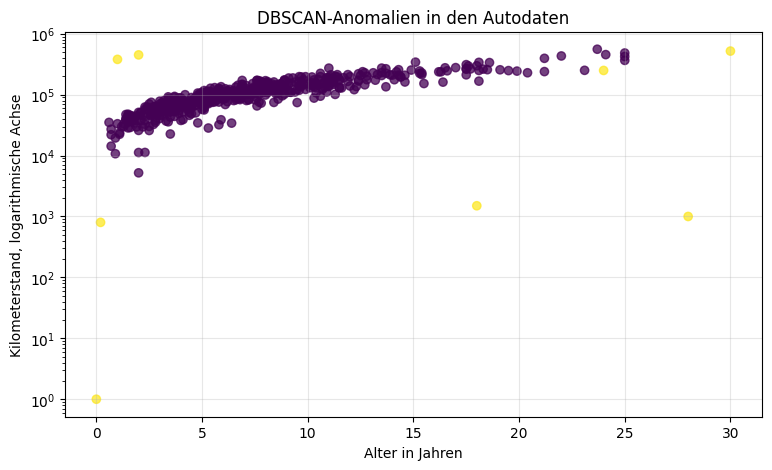

In [13]:
# Zweidimensionale Projektion zur visuellen Kontrolle.
# Die y-Achse wird logarithmisch dargestellt, weil Kilometerstände
# stark unterschiedliche Größenordnungen besitzen.
plt.figure(figsize=(9, 5))

streudiagramm = plt.scatter(
    df["Alter"],
    df["Kilometerstand"] + 1,  # +1 erlaubt die logarithmische Darstellung von 0 km
    c=df["DBSCAN_Anomalie"].astype(int),
    alpha=0.75,
)

plt.yscale("log")
plt.xlabel("Alter in Jahren")
plt.ylabel("Kilometerstand, logarithmische Achse")
plt.title("DBSCAN-Anomalien in den Autodaten")
plt.grid(alpha=0.3)
plt.show()

## 9. Bewertung der Ergebnisse

Für reale Daten sollte man die Parameter nicht allein nach der Anzahl gefundener Ausreißer auswählen.

Eine sinnvolle Vorgehensweise ist:

1. Merkmale fachlich auswählen.
2. schiefe Verteilungen gegebenenfalls transformieren.
3. Merkmale skalieren.
4. `min_samples` anhand der Dimension und der gewünschten Mindestdichte wählen.
5. `eps` mit dem k-Distanz-Plot abschätzen.
6. benachbarte Parameterwerte testen.
7. gefundene Fälle fachlich prüfen.
8. untersuchen, welche Punkte bei mehreren Einstellungen stabil auffällig bleiben.

### Wichtige Grenzen

- DBSCAN erkennt ungewöhnliche Punkte, aber keine „Fehler“ im fachlichen Sinn.
- Unterschiedlich dichte Fahrzeuggruppen können problematisch sein.
- Kategoriale Merkmale wie Marke oder Fahrzeugtyp lassen sich nicht ohne Weiteres mit der euklidischen Distanz kombinieren.
- Bei vielen Merkmalen verlieren Distanzen an Aussagekraft.
- Für unterschiedlich dichte Cluster kann HDBSCAN geeigneter sein.
- Für allgemeine tabellarische Anomalieerkennung sind auch Isolation Forest und Local Outlier Factor sinnvolle Vergleichsverfahren.